In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:

def import_csv(url):
  path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
  return pd.read_csv(path)
    
orderlines_url = "https://docs.google.com/spreadsheets/d/1pe8NPH3o4yATyuOHPUNO2eYxqRkEwFSi/edit?usp=sharing&ouid=113932356050340512162&rtpof=true&sd=true"
orders_url = "https://docs.google.com/spreadsheets/d/1nnfvVR3TW6Voa8qipZB4xFakqDGRf54l/edit?usp=sharing&ouid=113932356050340512162&rtpof=true&sd=true"
products_url = " https://docs.google.com/spreadsheets/d/16yk9NqhYgB3XAZOhMLsrkwe7IVDSUhax/edit?usp=sharing&ouid=113932356050340512162&rtpof=true&sd=true"
brands_url = "https://docs.google.com/spreadsheets/d/1tjrDe54jGO6T3uoC_LEhypSTs1WtQZ72/edit?usp=sharing&ouid=113932356050340512162&rtpof=true&sd=true"


orderlines_qua = import_csv(orderlines_url)
orders_qua = import_csv(orders_url)
products_cl = import_csv(products_url)
brands_cl = import_csv(brands_url)

In [74]:
orderlines_qua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57974 entries, 0 to 57973
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                57974 non-null  int64  
 1   id_order          57974 non-null  int64  
 2   product_id        57974 non-null  int64  
 3   product_quantity  57974 non-null  int64  
 4   sku               57974 non-null  object 
 5   unit_price        57974 non-null  float64
 6   date              57974 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 3.1+ MB


In [75]:
orders_qua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44145 entries, 0 to 44144
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      44145 non-null  int64  
 1   created_date  44145 non-null  object 
 2   total_paid    44145 non-null  float64
 3   state         44145 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.3+ MB


In [76]:
orderlines_df =   orderlines_qua.copy()

In [77]:
orders_df = orders_qua.copy()

In [78]:
products_df = products_cl.copy()

In [79]:
brands_df = brands_cl.copy()

In [80]:
                                    #######  merged products and orderlines

In [81]:
products_orderlines = orderlines_df.merge(products_df[["sku", "name", "price"]],how="left",on="sku")


In [82]:
products_orderlines.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57974 entries, 0 to 57973
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                57974 non-null  int64  
 1   id_order          57974 non-null  int64  
 2   product_id        57974 non-null  int64  
 3   product_quantity  57974 non-null  int64  
 4   sku               57974 non-null  object 
 5   unit_price        57974 non-null  float64
 6   date              57974 non-null  object 
 7   name              57974 non-null  object 
 8   price             57974 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 4.0+ MB


In [83]:
products_orderlines.describe()

,id,id_order,product_id,product_quantity,unit_price,price
count,5.797400e+04,57974.000000,57974.0,57974.000000,57974.000000,57974.000000
mean,1.386625e+06,414890.542312,0.0,1.120934,239.146592,276.535932
std,1.504158e+05,65299.660990,0.0,0.787421,502.544279,564.829558
min,1.119116e+06,241423.000000,0.0,1.000000,0.010000,2.990000
25%,1.267590e+06,363588.500000,0.0,1.000000,29.740000,39.950000
50%,1.390602e+06,417813.000000,0.0,1.000000,69.990000,89.990000
75%,1.513844e+06,470113.250000,0.0,1.000000,184.990000,219.990000
max,1.649593e+06,527112.000000,0.0,72.000000,8287.800000,9799.000000


In [84]:
products_orderlines_df = products_orderlines.copy()

In [85]:
products_orderlines["unit_price"].isna().sum()

np.int64(0)

In [86]:
                                            ####### how many products are discounted?

In [87]:
# price - unit_price

In [88]:
products_orderlines_df.loc[:,'discount'] =( products_orderlines_df['price'] - products_orderlines_df['unit_price'])

In [89]:
products_orderlines_df.loc[:,['sku','price','unit_price','discount']].head(10)

,sku,price,unit_price,discount
0,OWC0100,60.99,47.49,13.50
1,IOT0014,22.95,18.99,3.96
2,APP0700,89.00,72.19,16.81
3,PAC0929,3209.00,2565.99,643.01
4,CRU0039-A,76.99,60.90,16.09
5,PEB0015,299.99,142.49,157.50
6,BEA0065,299.95,256.49,43.46
7,SAT0010,29.99,18.99,11.00
8,SYN0139,175.99,166.24,9.75
9,LOG0191,209.00,142.49,66.51


In [90]:
products_orderlines_df.loc[:,['sku','price','unit_price','discount']].tail(10)

,sku,price,unit_price,discount
57964,APP0698,25.0,9.99,15.01
57965,APP0927,35.0,13.99,21.01
57966,APP0498,25.0,23.00,2.00
57967,APP0927,35.0,13.99,21.01
57968,APP0927,35.0,13.99,21.01
57969,APP0698,25.0,9.99,15.01
57970,APP0698,25.0,9.99,15.01
57971,APP0698,25.0,9.99,15.01
57972,APP0698,25.0,9.99,15.01
57973,APP0698,25.0,9.99,15.01


In [91]:
                                                    ####### products without discount

In [92]:
products_orderlines_df.loc[(products_orderlines_df['discount']<= 0)]['sku'].count()

np.int64(4074)

In [93]:
products_orderlines_df.loc[(products_orderlines_df['discount']<= 0)]['sku'].nunique()

794

In [94]:
                                                       ####### products with discount

In [95]:
discount_products = products_orderlines_df.loc[(products_orderlines_df['discount']> 0)]['sku'].count()
discount_products

np.int64(53900)

In [96]:
products_orderlines_df.loc[(products_orderlines_df['discount']> 0)]['sku'].nunique()


5526

In [97]:
               ##########  how big are the offered discounts ( % percentage of product price)?

In [98]:
products_orderlines_df.loc[:,'percentage_of_discount'] =(products_orderlines_df['discount']/products_orderlines_df['price'])*100
products_orderlines_df['percentage_of_discount']




0        22.134776
1        17.254902
2        18.887640
3        20.037706
4        20.898818
           ...    
57969    60.040000
57970    60.040000
57971    60.040000
57972    60.040000
57973    60.040000
Name: percentage_of_discount, Length: 57974, dtype: float64

In [99]:
def discount_category(x):
    if x <= 0:
        return 'No discount'
    elif x <= 10:
        return '0-10%'
    elif x <= 20:
        return '10-20%'
    elif x <= 30:
        return '20-30%'
    else:
        return '30%+'


In [100]:
products_orderlines_df.loc[:,'discount_category'] = products_orderlines_df['percentage_of_discount'].apply(discount_category)
sold_product =(
    products_orderlines_df["discount_category"]
    .value_counts()
    .reindex(["No discount", "0-10%", "10-20%", "20-30%", "30%+"])
)

sold_product

discount_category
No discount     4074
0-10%          13022
10-20%         16300
20-30%         12025
30%+           12553
Name: count, dtype: int64

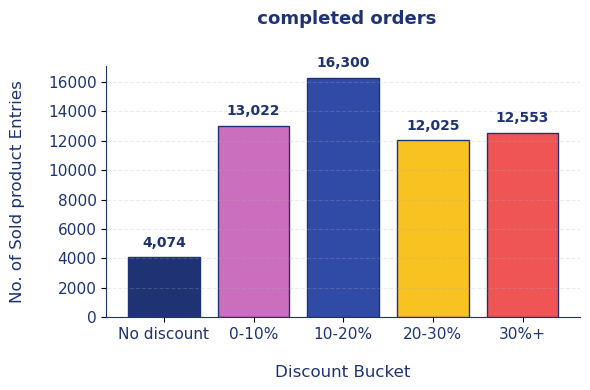

In [101]:
# Discount vs Unis Sold entries


plt.figure(figsize=(6,4))
# PPT colors
navy = "#1f3374"
blue = "#304ba6"
purple = "#cb6ebe"
yellow = "#f8c220"
red = "#f05555"

colors = [navy, purple, blue, yellow, red]
ax = plt.bar(
    sold_product.index,
    sold_product.values,
    color=colors,
   
     edgecolor='#1f3374',
    linewidth=1
)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.title('Number of completed Orders\n',
    fontsize=14,
    fontweight='bold'
)
for bar in ax:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 500,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=navy
    )

plt.title(
    " completed orders\n ",
    fontsize=13,
    fontweight="bold",
    color=navy,
    pad=15
)

plt.xlabel('\nDiscount Bucket',fontsize=12, color='#1F3374')
plt.ylabel('No. of Sold product Entries\n',fontsize=12, color='#1F3374')

plt.xticks(fontsize=11, color=navy)
plt.yticks(fontsize=11, color=navy)

plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_color(navy)
plt.gca().spines["bottom"].set_color(navy)

plt.tight_layout()

plt.show()

In [102]:
products_orderlines_df.loc[:,'Total_Revenue'] = products_orderlines_df['unit_price']*products_orderlines_df['product_quantity']

In [103]:
 # average revenue per order
products_orderlines_df['Avg_rev_per_product'] = products_orderlines_df['Total_Revenue']/products_orderlines_df['product_quantity']
discount_analysis = products_orderlines_df.groupby('discount_category').agg({'product_quantity':'sum','Total_Revenue': 'sum','Avg_rev_per_product':'mean'}).reset_index()
order = ['No discount','0-10%','10-20%','20-30%','30%+']
discount_analysis['discount_category'] = pd.Categorical(discount_analysis['discount_category'],categories = order,ordered=True)
discount_analysis = discount_analysis.sort_values('discount_category')

In [104]:
discount_analysis

,discount_category,product_quantity,Total_Revenue,Avg_rev_per_product
4,No discount,4613,748228.42,169.640893
0,0-10%,14292,6909285.91,510.111500
1,10-20%,18267,4145589.21,241.435509
2,20-30%,13639,2096049.46,160.534990
3,30%+,14174,721591.47,52.948581


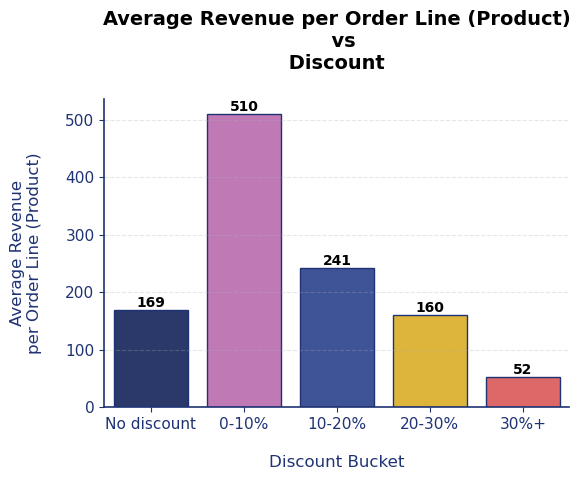

In [141]:
plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=discount_analysis,
    x='discount_category',
    y='Avg_rev_per_product',
   palette = ['#1f3374', '#cb6ebe','#304ba6', '#f8c220', '#f05555'],
    hue='discount_category',
     edgecolor='#1F3374',
    legend=False
)

# Clean look improvements
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.title(
    'Average Revenue per Order Line (Product)\n  vs\n Discount \n',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('\nDiscount Bucket',fontsize=12, color='#1F3374')
plt.ylabel('Average Revenue\nper Order Line (Product)\n',fontsize=12, color='#1F3374')
# X-axis tick labels (0%, 10%, etc.)
ax.tick_params(axis='x', colors='#1F3374', labelsize=11)

# Left Y-axis (Average revenue)
ax.tick_params(axis='y', colors='#1F3374', labelsize=11)

# Left spine
ax.spines['left'].set_color('#1F3374')

# Bottom spine
ax.spines['bottom'].set_color('#1F3374')

ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)


for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10, fontweight='bold')

plt.show()

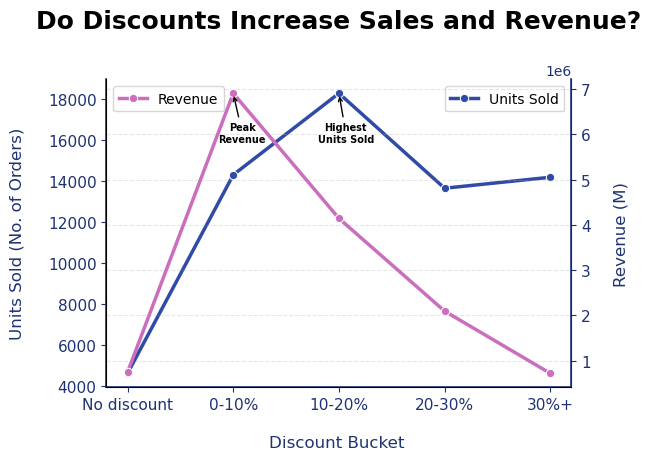

In [106]:
fig, ax1 = plt.subplots(figsize=(6,4))

# =======================
# Units Sold (Left Axis)
# =======================
sns.lineplot(
    data=discount_analysis,
    x='discount_category',
    y='product_quantity',
    marker='o',
    linewidth=2.5,
    color='#304ba6',
    label='Units Sold',
  
     ax=ax1
)

ax1.set_ylabel('Units Sold (No. of Orders)\n',fontsize=12, color='#1F3374')
ax1.set_xlabel('\nDiscount Bucket ', fontsize=12, color='#1F3374')

# =======================
# Revenue (Right Axis)
# =======================
ax2 = ax1.twinx()

sns.lineplot(
    data=discount_analysis,
    x='discount_category',
    y='Total_Revenue',
    marker='o',
    linewidth=2.5,
    color='#cb6ebe',
    label='Revenue',
  
    ax=ax2
)

ax2.set_ylabel('\nRevenue (M)',fontsize=12, color='#1F3374')

# Right axis formatting (important)
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()

# =======================
# Find Peaks
# =======================

# Units Sold Peak
max_units_idx = discount_analysis['product_quantity'].idxmax()
x_units = discount_analysis.loc[max_units_idx, 'discount_category']
y_units = discount_analysis.loc[max_units_idx, 'product_quantity']

# Revenue Peak  
max_rev_idx = discount_analysis['Total_Revenue'].idxmax()
x_rev = discount_analysis.loc[max_rev_idx, 'discount_category']
y_rev = discount_analysis.loc[max_rev_idx, 'Total_Revenue']

# =======================
# Annotations
# =======================

ax1.annotate(
    'Highest\nUnits Sold',
    xy=(x_units, y_units),
    xytext=(5, -35),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->'),
     fontweight='bold',
    fontsize=7,
    ha='center'
)

ax2.annotate(
    'Peak\nRevenue',
    xy=(x_rev, y_rev),
    xytext=(6.5, -35),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->'),
    fontweight='bold',
    fontsize=7,
    ha='center'
)

# =======================
# Styling
# =======================

# --- REMOVE TOP BORDER ONLY ---

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# --- KEEP RIGHT BORDER (IMPORTANT) ---
ax2.spines['right'].set_linewidth(1)

plt.grid(axis='y', linestyle='--', alpha=0.3)

# X-axis tick labels (0%, 10%, etc.)
ax1.tick_params(axis='x', colors='#1F3374', labelsize=11)

# Left Y-axis (Units Sold)
ax1.tick_params(axis='y', colors='#1F3374', labelsize=11)

# Right Y-axis (Revenue)
ax2.tick_params(axis='y', colors='#1F3374', labelsize=11)

# Spine Colors
# =======================

# Left spine
ax1.spines['left'].set_color('#1F3374')

# Bottom spine
ax1.spines['bottom'].set_color('#1F3374')

# Right spine (belongs to ax2 in twin axis)
ax2.spines['right'].set_color('#1F3374')

ax1.spines['left'].set_linewidth(1.2)
ax1.spines['bottom'].set_linewidth(1.2)
ax2.spines['right'].set_linewidth(1.2)


# =======================
# Title
# =======================
plt.title(
    'Do Discounts Increase Sales and Revenue?\n',
    fontsize=18,
    fontweight='bold'
)


# =======================
# Legends (separate & clean)
# =======================
ax1.legend(loc='upper right')
ax2.legend(loc='upper left')

plt.show()

In [107]:
products_orderlines_df['brands'] = products_orderlines_df['sku'].str[0:3]
products_orderlines_df['brands']

0        OWC
1        IOT
2        APP
3        PAC
4        CRU
        ... 
57969    APP
57970    APP
57971    APP
57972    APP
57973    APP
Name: brands, Length: 57974, dtype: object

In [108]:
products_orderlines['brands'] = products_orderlines['sku'].str[0:3]
products_orderlines['brands']

0        OWC
1        IOT
2        APP
3        PAC
4        CRU
        ... 
57969    APP
57970    APP
57971    APP
57972    APP
57973    APP
Name: brands, Length: 57974, dtype: object

In [109]:
##### merging with brands

In [110]:
products_orderlines_brands = products_orderlines_df.merge(brands_df, how ='left',left_on ='brands',right_on ='short')
products_orderlines_brands.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57974 entries, 0 to 57973
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      57974 non-null  int64  
 1   id_order                57974 non-null  int64  
 2   product_id              57974 non-null  int64  
 3   product_quantity        57974 non-null  int64  
 4   sku                     57974 non-null  object 
 5   unit_price              57974 non-null  float64
 6   date                    57974 non-null  object 
 7   name                    57974 non-null  object 
 8   price                   57974 non-null  float64
 9   discount                57974 non-null  float64
 10  percentage_of_discount  57974 non-null  float64
 11  discount_category       57974 non-null  object 
 12  Total_Revenue           57974 non-null  float64
 13  Avg_rev_per_product     57974 non-null  float64
 14  brands                  57974 non-null

In [111]:
products_orderlines_brands_df = products_orderlines_brands.copy()

In [112]:
brands_df['short'].nunique()

187

In [113]:
products_orderlines_brands_df['brands'].nunique()

197

In [114]:
products_orderlines_brands_df['date'] = pd.to_datetime(products_orderlines_brands_df['date'])

In [115]:
products_orderlines_brands_df.loc[:,'Brand_Revenue'] = products_orderlines_brands_df['product_quantity']*products_orderlines_brands_df['unit_price']

In [116]:
products_orderlines_brands_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57974 entries, 0 to 57973
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      57974 non-null  int64         
 1   id_order                57974 non-null  int64         
 2   product_id              57974 non-null  int64         
 3   product_quantity        57974 non-null  int64         
 4   sku                     57974 non-null  object        
 5   unit_price              57974 non-null  float64       
 6   date                    57974 non-null  datetime64[ns]
 7   name                    57974 non-null  object        
 8   price                   57974 non-null  float64       
 9   discount                57974 non-null  float64       
 10  percentage_of_discount  57974 non-null  float64       
 11  discount_category       57974 non-null  object        
 12  Total_Revenue           57974 non-null  float6

In [117]:
#######complete seasonal analysis

In [118]:

# Convert date
products_orderlines_brands_df['date'] = pd.to_datetime(
    products_orderlines_brands_df['date']
)

# Extract year + month
products_orderlines_brands_df['year'] = products_orderlines_brands_df['date'].dt.year
products_orderlines_brands_df['month'] = products_orderlines_brands_df['date'].dt.month_name()

In [119]:
seasonal = (
    products_orderlines_brands_df
    .groupby(['year', 'month'])['Total_Revenue']
    .sum()
    .reset_index()
)

In [120]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

seasonal['month'] = pd.Categorical(
    seasonal['month'],
    categories=month_order,
    ordered=True
)

seasonal = seasonal.sort_values(['year', 'month'])

In [121]:
seasonal = seasonal.sort_values(['year', 'month'])

# Create year_month column
seasonal['year_month'] = (
    seasonal['year'].astype(str) + '-' + seasonal['month'].astype(str)
)

# Convert to ordered categorical
seasonal['year_month'] = pd.Categorical(
    seasonal['year_month'],
    categories=seasonal['year_month'].tolist(),
    ordered=True
)



In [122]:
seasonal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 4 to 14
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   year           15 non-null     int32   
 1   month          15 non-null     category
 2   Total_Revenue  15 non-null     float64 
 3   year_month     15 non-null     category
dtypes: category(2), float64(1), int32(1)
memory usage: 1.4 KB


In [123]:
seasonal = seasonal.sort_values(['year', 'month'])

seasonal['year_month'] = seasonal['year'].astype(str) + '-' + seasonal['month'].astype(str).str.zfill(2)
seasonal['year_month']

4       2017-January
3      2017-February
7         2017-March
0         2017-April
8           2017-May
6          2017-June
5          2017-July
1        2017-August
11    2017-September
10      2017-October
9      2017-November
2      2017-December
13      2018-January
12     2018-February
14        2018-March
Name: year_month, dtype: object

In [124]:
seasonal = products_orderlines_brands_df.groupby(['year','month']).agg( revenue=('Total_Revenue','sum'), units=('id','count'), discount=('percentage_of_discount','mean') ).reset_index()

In [125]:
seasonal['month'] = seasonal['month'].astype(str).str.strip()


In [126]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

month_map = {m: i for i, m in enumerate(month_order, 1)}

seasonal['month_num'] = seasonal['month'].map(month_map)

In [127]:
seasonal = seasonal.sort_values(['year','month_num'])

In [128]:
seasonal['year_month'] = seasonal['year'].astype(str) + '-' + seasonal['month_num'].astype(str).str.zfill(2)

In [129]:
seasonal

,year,month,revenue,units,discount,month_num,year_month
4,2017,January,1110203.36,6333,24.218425,1,2017-01
3,2017,February,575763.98,2725,19.076796,2,2017-02
7,2017,March,114803.53,270,17.600137,3,2017-03
0,2017,April,411374.88,2015,17.705351,4,2017-04
8,2017,May,571891.36,2355,14.882408,5,2017-05
6,2017,June,607587.44,1956,16.246144,6,2017-06
5,2017,July,992435.83,4394,24.080542,7,2017-07
1,2017,August,680085.47,2904,19.795678,8,2017-08
11,2017,September,835720.36,2798,19.391449,9,2017-09
10,2017,October,1035493.39,3928,21.151630,10,2017-10


In [130]:
seasonal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 4 to 14
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        15 non-null     int32  
 1   month       15 non-null     object 
 2   revenue     15 non-null     float64
 3   units       15 non-null     int64  
 4   discount    15 non-null     float64
 5   month_num   15 non-null     int64  
 6   year_month  15 non-null     object 
dtypes: float64(2), int32(1), int64(2), object(2)
memory usage: 900.0+ bytes


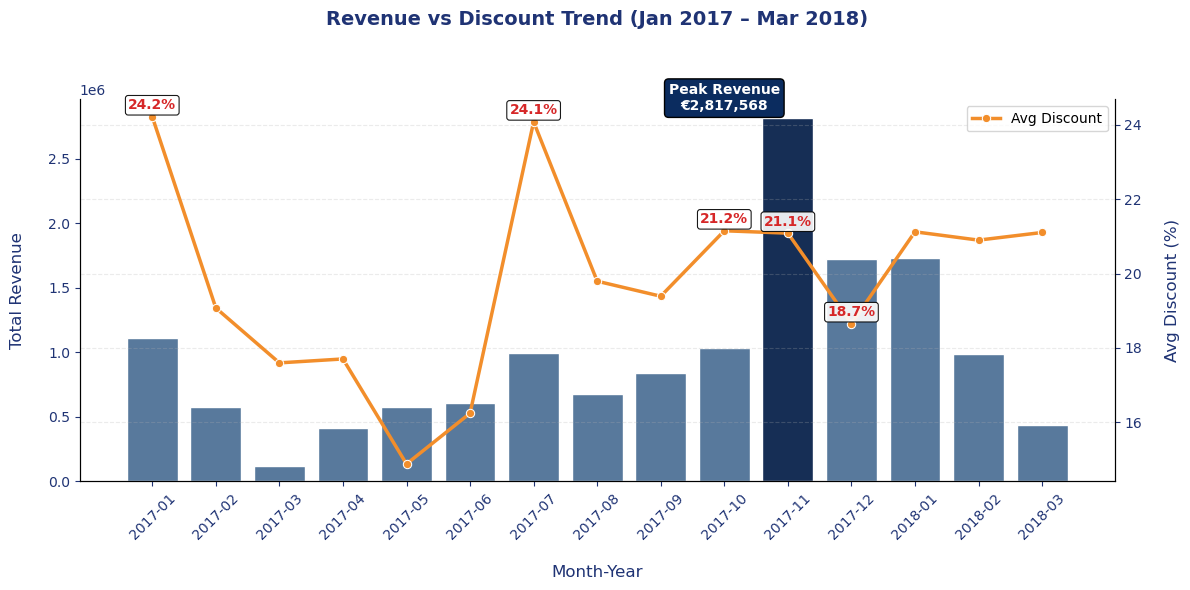

In [139]:
fig, ax1 = plt.subplots(figsize=(12,6))

navy = "#1F3374"
bar_color = "#4C78A8"
peak_bar_color = "#0B2C5F"
line_color = "#F28E2B"

# =======================
# 🔥 PEAK REVENUE (INLINE)
# =======================
peak_rev_month = seasonal.loc[
    seasonal['revenue'].idxmax(),
    'year_month'
]

colors = [
    peak_bar_color if x == peak_rev_month else bar_color
    for x in seasonal['year_month']
]

# =======================
# BAR → Revenue
# =======================
sns.barplot(
    data=seasonal,
    x='year_month',
    y='revenue',
    palette=colors,
    hue='year_month',
    edgecolor='white',
    legend=False,
    ax=ax1
)

ax1.set_ylabel('Total Revenue\n', fontsize=12, color=navy)
ax1.set_xlabel('\nMonth-Year', fontsize=12, color=navy)

ax1.tick_params(axis='x', rotation=45, colors=navy)
ax1.tick_params(axis='y', colors=navy)

# =======================
# 🔥 LABEL PEAK REVENUE
# =======================
peak_row = seasonal.loc[seasonal['revenue'].idxmax()]

for i, row in seasonal.iterrows():

    if row['year_month'] == peak_row['year_month']:

        ax1.text(
            i,
            row['revenue'] + seasonal['revenue'].max()*0.02,
            f"Peak Revenue\n€{row['revenue']:,.0f}",
            ha='center',
            fontsize=10,
            fontweight='bold',
            color='white',
            bbox=dict(
                facecolor=peak_bar_color,
                edgecolor='black',
                boxstyle='round,pad=0.3'
            )
        )

# =======================
# LINE → Discount
# =======================
ax2 = ax1.twinx()

sns.lineplot(
    data=seasonal,
    x='year_month',
    y='discount',
    color=line_color,
    marker='o',
    linewidth=2.5,
    errorbar=None,
    ax=ax2,
    label='Avg Discount'
)

ax2.set_ylabel('\nAvg Discount (%)', fontsize=12, color=navy)
ax2.tick_params(axis='y', colors=navy)

# =======================
# 🔥 LABELS (July + Q4 + Peak discount)
# =======================
target_months = ['July', 'October', 'November', 'December']

selected = seasonal[
    seasonal['month'].isin(target_months)
]

peak_discount = seasonal.loc[
    seasonal['discount'].idxmax()
]

final_points = pd.concat([
    selected,
    peak_discount.to_frame().T
]).drop_duplicates()

xticks = ax1.get_xticks()

xlabels = [
    tick.get_text()
    for tick in ax1.get_xticklabels()
]

for _, row in final_points.iterrows():

    if row['year_month'] in xlabels:

        idx = xlabels.index(row['year_month'])
        x = xticks[idx]

        ax2.text(
            x,
            row['discount'] + 0.2,
            f"{row['discount']:.1f}%",
            ha='center',
            fontsize=10,
            fontweight='bold',
            color="#D62728",
            bbox=dict(
                facecolor='white',
                edgecolor='black',
                linewidth=0.8,
                alpha=0.9,
                boxstyle='round,pad=0.2'
            )
        )
# =======================
# SIMPLE LEGEND
# =======================
ax1.bar([], [], color='white', label='Revenue')
ax2.plot([], [], color=line_color, marker='o',
         linewidth=2.5, label='Avg Discount')


# =======================
# STYLING
# =======================
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.title(
    'Revenue vs Discount Trend (Jan 2017 – Mar 2018)\n\n\n',
    fontsize=14,
    fontweight='bold',
    color=navy
)

plt.grid(axis='y', linestyle='--', alpha=0.25)

plt.tight_layout()
plt.show()

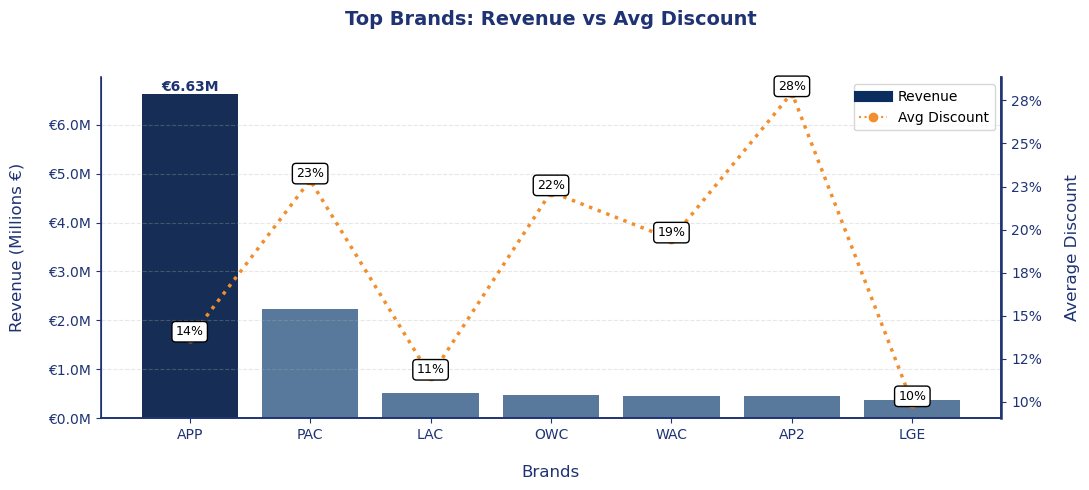

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# -----------------------------
# COLORS
# -----------------------------
navy = "#1F3374"
bar_color = "#4C78A8"
peak_bar_color = "#0B2C5F"
line_color = "#F28E2B"

# -----------------------------
# STEP 0: FIX DISCOUNT SCALE
# -----------------------------
if products_orderlines_brands_df['percentage_of_discount'].max() > 1:
    products_orderlines_brands_df['percentage_of_discount'] = (
        products_orderlines_brands_df['percentage_of_discount'] / 100
    )

# -----------------------------
# STEP 1: AGGREGATE
# -----------------------------
brand_summary = (
    products_orderlines_brands_df
    .groupby('brands')
    .agg(
        total_revenue=('Brand_Revenue', 'sum'),
        avg_discount=('percentage_of_discount', 'mean')
    )
    .reset_index()
)

# convert revenue to millions
brand_summary['total_revenue_m'] = brand_summary['total_revenue'] / 1_000_000

# -----------------------------
# STEP 2: TOP 7
# -----------------------------
top7 = (
    brand_summary
    .sort_values('total_revenue_m', ascending=False)
    .head(7)
    .reset_index(drop=True)
)

top7 = top7.sort_values('total_revenue_m', ascending=False).reset_index(drop=True)

# -----------------------------
# COLORS
# -----------------------------
colors = [bar_color] * len(top7)
colors[0] = peak_bar_color

# -----------------------------
# PLOT
# -----------------------------
fig, ax1 = plt.subplots(figsize=(11, 5))

# BAR → Revenue
sns.barplot(
    data=top7,
    x='brands',
    y='total_revenue_m',
    palette=colors,
    hue='brands',
    ax=ax1
)

ax1.set_title(
    'Top Brands: Revenue vs Avg Discount\n\n',
    fontsize=14,
    fontweight='bold',
    color=navy
)

ax1.set_xlabel('\nBrands', color=navy,fontsize=12)
ax1.set_ylabel('Revenue (Millions €)\n', color=navy,fontsize=12)

# grid
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# format revenue axis
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'€{x:.1f}M'))

# -----------------------------
# FULL BORDER (LEFT PLOT)
# -----------------------------
ax1.spines['top'].set_visible(True)
ax1.spines['right'].set_visible(True)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)

ax1.spines['top'].set_color(navy)
ax1.spines['right'].set_color(navy)
ax1.spines['bottom'].set_color(navy)
ax1.spines['left'].set_color(navy)

ax1.spines['top'].set_linewidth(1.2)
ax1.spines['right'].set_linewidth(1.2)
ax1.spines['bottom'].set_linewidth(1.2)
ax1.spines['left'].set_linewidth(1.2)

# -----------------------------
# LABEL ONLY TOP REVENUE
# -----------------------------
max_idx = top7['total_revenue_m'].idxmax()
max_value = top7['total_revenue_m'].max()

ax1.text(
    max_idx,
    max_value,
    f"€{max_value:.2f}M",
    ha='center',
    va='bottom',
    fontsize=10,
    fontweight='bold',
    color=navy
)

# -----------------------------
# RIGHT AXIS (DISCOUNT)
# -----------------------------
ax2 = ax1.twinx()

ax2.plot(
    top7['brands'],
    top7['avg_discount'],
    color=line_color,
    marker='o',
    linestyle=':',
    linewidth=2.5
)

ax2.set_ylabel('\nAverage Discount', color=navy,fontsize=12)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))

# -----------------------------
# FULL BORDER (RIGHT AXIS)
# -----------------------------
ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(True)
ax2.spines['bottom'].set_visible(True)
ax2.spines['left'].set_visible(True)

ax2.spines['top'].set_color(navy)
ax2.spines['right'].set_color(navy)
ax2.spines['bottom'].set_color(navy)
ax2.spines['left'].set_color(navy)

ax2.spines['top'].set_linewidth(1.2)
ax2.spines['right'].set_linewidth(1.8)  # stronger right border
ax2.spines['bottom'].set_linewidth(1.2)
ax2.spines['left'].set_visible(False)    # avoid overlap in twin axis

# -----------------------------
# TICK COLORS
# -----------------------------
ax1.tick_params(axis='x', colors=navy, labelsize=10)
ax1.tick_params(axis='y', colors=navy, labelsize=10)

ax2.tick_params(axis='y', colors=navy, labelsize=10)

# -----------------------------
# DISCOUNT BOX LABELS
# -----------------------------
for i, v in enumerate(top7['avg_discount']):
    ax2.text(
        i,
        v,
        f"{v:.0%}",
        ha='center',
        va='bottom',
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            linewidth=1
        )
    )

# -----------------------------
# LEGEND
# -----------------------------
legend1 = plt.Line2D([0], [0], color=peak_bar_color, lw=8, label='Revenue')
legend2 = plt.Line2D([0], [0], color=line_color, linestyle=':', marker='o', label='Avg Discount')

ax1.legend(handles=[legend1, legend2], loc='upper right')

sns.despine(left=False, right=False)
plt.tight_layout()
plt.show()

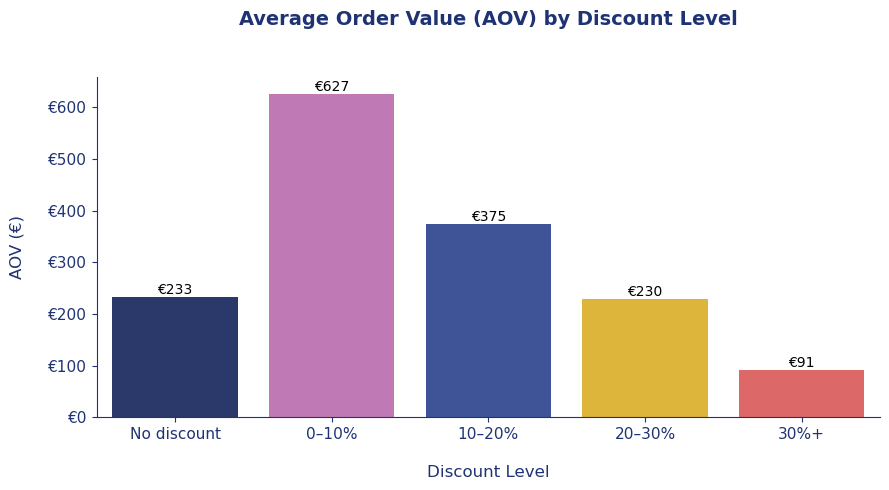

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# -----------------------------
# STEP 1: Revenue per order
# -----------------------------
order_level = (
    products_orderlines_brands_df
    .groupby('id_order')
    .agg(
        order_revenue=('Brand_Revenue', 'sum'),
        avg_discount=('percentage_of_discount', 'mean')
    )
    .reset_index()
)

# -----------------------------
# STEP 2: Discount categories
# -----------------------------
def discount_category(x):
    if x <= 0:
        return 'No discount'
    elif x <= 0.10:
        return '0–10%'
    elif x <= 0.20:
        return '10–20%'
    elif x <= 0.30:
        return '20–30%'
    else:
        return '30%+'

order_level['discount_level'] = order_level['avg_discount'].apply(discount_category)

# enforce order
order = ['No discount', '0–10%', '10–20%', '20–30%', '30%+']
order_level['discount_level'] = pd.Categorical(order_level['discount_level'], categories=order, ordered=True)

# -----------------------------
# STEP 3: Average Order Value
# -----------------------------
aov = (
    order_level
    .groupby('discount_level', observed=True)['order_revenue']
    .mean()
    .reset_index()
)

# -----------------------------
# STEP 4: PLOT
# -----------------------------
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=aov,
    x='discount_level',
    y='order_revenue',
    hue='discount_level',
   palette = ['#1f3374', '#cb6ebe','#304ba6', '#f8c220', '#f05555'],
)

plt.title('Average Order Value (AOV) by Discount Level\n\n', fontsize=14, fontweight='bold',color='#1F3374')
plt.xlabel('\nDiscount Level',fontsize=12, color='#1F3374')
plt.ylabel('AOV (€)\n',fontsize=12, color='#1F3374')

# X-axis tick labels (0%, 10%, etc.)
ax.tick_params(axis='x', colors='#1F3374', labelsize=11)

# Left Y-axis (Average revenue)
ax.tick_params(axis='y', colors='#1F3374', labelsize=11)

# Left spine
ax.spines['left'].set_color('#1F3374')

# Bottom spine
ax.spines['bottom'].set_color('#1F3374')

# format in euros
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'€{x:,.0f}'))

# value labels
for container in ax.containers:
    ax.bar_label(container, fmt='€%.0f', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()